# Information Extraction - Exploratory Notebook - Cross Validation Model
## Purpose
Changes to this notebook

- Cross validation
- Feature importance
- ROC analysis
---
---


## Step 1: Import packages and dataset
As before, we use the requirements.txt file to install our required packages.

In [2]:
# Before we import our packages, we need to have the installed on our local machine. Use a combinaion of pip and the requirements.txt file for this.
# note, remove the -q flag to increase verbosity. 
#  ths is what you should be seeing
%pip install -q -r requirements.txt

You should consider upgrading via the '/Users/sbrv951/Documents/CodeLibrary/MissingDataPredictor/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# import packages into our python environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, auc
import re
import time



In [4]:
# install data
data = pd.read_csv('crime_data.csv')

/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_57623/2338300253.py:2: DtypeWarning: Columns (16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('crime_data.csv')


## Step 2: Remap Vict-Offender Relationship column with new labels
As before, we now need to remap the 56 labels in the Vict-Offender Relationship column with the new macro labels.

In [6]:
# filter the dataframe to include only the columns we're interested in
cols = [
    'VIC OFFENDER RELATIONSHIP',
    'CRIME NOTES'
]

data_f = data[cols]

# remove NaNs
data_f3 = data_f.dropna(subset=['CRIME NOTES','VIC OFFENDER RELATIONSHIP'])

# separate the rows where VIC OFFENDER RELATIONSHIP is empty and store that as an unlabelled dataset.
unlabelled_data = data_f3[data_f3['VIC OFFENDER RELATIONSHIP'].isna()]


In [7]:
# use the vic_offender_remapping.csv file to map exiting categories to new ones
mapping_df = pd.read_csv('v2_vic_offender_remapping.csv', delimiter=',')
mapping_df.columns = mapping_df.columns.str.strip()

# map the values in the VIC OFFENDER COLUMN to the corresponding values in the mapping DF
data_f3.loc[:, 'remapped_cats'] = data_f3.loc[:, 'VIC OFFENDER RELATIONSHIP'].map(mapping_df.set_index('value')['mapping'])
print(len(data_f3))
data_f3.head(10)

14081


/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_57623/1825331738.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f3.loc[:, 'remapped_cats'] = data_f3.loc[:, 'VIC OFFENDER RELATIONSHIP'].map(mapping_df.set_index('value')['mapping'])


,VIC OFFENDER RELATIONSHIP,CRIME NOTES,remapped_cats
2,BOYFRIEND/GIRLFRIEND,MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...,partner
3,EX PARTNER,THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...,ex_partner
4,BOYFRIEND/GIRLFRIEND,KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...,partner
5,EX PARTNER,SUSPECT HAS APPROACHED EX PARTNER WHILST HER V...,ex_partner
6,OTHER,HAPPENED 06/07/16 APPROX 0600 HOURS ON THE INF...,other
7,BOYFRIEND/GIRLFRIEND,FEMALE HAS BEEN AT HOME WITH HER CHILDREN WHEN...,partner
8,EX PARTNER,POLICE CALLED TO VERBAL ONLY DOMESTIC. UPON HA...,ex_partner
9,BOYFRIEND/GIRLFRIEND,"B173***SEC 39 ASSAULT, THREATS TO KILL. DOMEST...",partner
10,BOYFRIEND/GIRLFRIEND,B162 CRIME *** SECTIO 47 ASSAULT****GOLD DOMES...,partner
11,BOYFRIEND/GIRLFRIEND,REPORT FROM THIRD PARTY THAT SUSPECT HAS MADE ...,partner


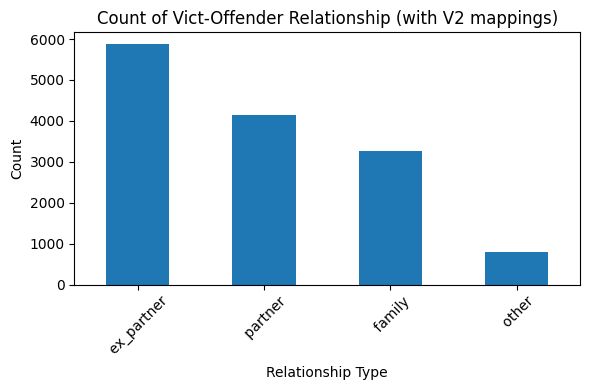

In [8]:
# we can now visualise a count of each type of relationship the remapped column
remapped_cats_counts = data_f3['remapped_cats'].value_counts()

# we can then create a bar chart demonstrating the counts
plt.figure(figsize=(6, 4))
remapped_cats_counts.plot(kind='bar')
plt.title('Count of Vict-Offender Relationship (with V2 mappings)')
plt.xlabel('Relationship Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/remapping_counts.png')
plt.show()

Compared with the previous version (v1), we now have four classes of relationship. 

In [9]:
# remove 'others' category
data_f3['remapped_cats'] = data_f3['remapped_cats'].str.strip().str.lower()
data_f4 = data_f3[data_f3['remapped_cats']!='other']

# check the filtered dataset
data_f4.shape

/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_57623/3906941531.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f3['remapped_cats'] = data_f3['remapped_cats'].str.strip().str.lower()


(13290, 3)

## Step 3: Clean the pre-process the unstructured text in the CRIME NOTES column.
This step continues to use the TF-IDF algorithm to engineer features.

In [10]:
# given that the text appears in upper casing, we should convert the text to lower casing as our algorithms will work better.
data_f4.loc[:, 'text_processed'] = data_f4['CRIME NOTES'].str.lower()

# we should also remove punctuation and numbers to reduce noise when training the model.
data_f4.loc[:, 'text_processed'] = data_f4.loc[:, 'text_processed'].apply(lambda x: re.sub(r'[^\w\s]|(\d+)','', x))

# download the list of stopwords 
nltk.download('stopwords')

# store the stop words in a Set
stop_words = set(stopwords.words('english'))

# search through each word in each row, and remove any words that appear in the list of stop words
data_f4.loc[:, 'text_processed_no_sw'] = data_f4['text_processed'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

# stem remaining words
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

# apply stemmer
data_f4.loc[:, 'text_processed_no_sw_stem'] = data_f4['text_processed_no_sw'].apply(lambda x: ' '.join(stemmer.stem(word) for word in x.split()))
data_f4.head()

/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_57623/1812056950.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f4.loc[:, 'text_processed'] = data_f4['CRIME NOTES'].str.lower()
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sbrv951/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_57623/1812056950.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f4.loc[:, 'text_processed_no_sw'] = 

,VIC OFFENDER RELATIONSHIP,CRIME NOTES,remapped_cats,text_processed,text_processed_no_sw,text_processed_no_sw_stem
2,BOYFRIEND/GIRLFRIEND,MARK PUSHES ZOE TO WAKE HER UP AND THIS RESULT...,partner,mark pushes zoe to wake her up and this result...,mark pushes zoe wake results bruised right thi...,mark push zoe wake result bruis right thigh re...
3,EX PARTNER,THIRD HAND REPORT OF DOMESTIC ASSAULT. PATROL ...,ex_partner,third hand report of domestic assault patrol a...,third hand report domestic assault patrol atte...,third hand report domest assault patrol attend...
4,BOYFRIEND/GIRLFRIEND,KNOWN OFFENDER CAUSED BROKEN BONES AND FACIAL ...,partner,known offender caused broken bones and facial ...,known offender caused broken bones facial inju...,known offend caus broken bone facial injuri ip...
5,EX PARTNER,SUSPECT HAS APPROACHED EX PARTNER WHILST HER V...,ex_partner,suspect has approached ex partner whilst her v...,suspect approached ex partner whilst vehicle s...,suspect approach ex partner whilst vehicl stat...
7,BOYFRIEND/GIRLFRIEND,FEMALE HAS BEEN AT HOME WITH HER CHILDREN WHEN...,partner,female has been at home with her children when...,female home children arguement ensued partner ...,femal home children arguement ensu partner own...


In [11]:
#  create X and y vectors
X = data_f4['text_processed_no_sw_stem']
y = data_f4['remapped_cats']

# init vectoriser
tfidf_vectorizer = TfidfVectorizer()

In [12]:
# define the paramater grid
param_grid = {
    'n_estimators': [20, 50, 80, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}

In [13]:
# init the random forest
rf = RandomForestClassifier(random_state=42)

In [14]:
# init the inner CV
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# init the outer CV
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)

In [15]:
# lists to store scores
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []
feature_importances = []

In [16]:
# training loop
import time

start = time.time()

# to store all predictions
all_predictions = pd.Series(index=y.index, dtype='float')

for train_idx, test_idx in outer_cv.split(X, y):
    
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)


    # X_train, X_test = X[train_idx], X[test_idx]
    # y_train, y_test = y[train_idx], y[test_idx]

    X_train = tfidf_vectorizer.fit_transform(X_train)
    X_test = tfidf_vectorizer.transform(X_test)
    
    # Grid search within the inner CV
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=inner_cv, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model from grid search
    best_model = grid_search.best_estimator_
    
    # Predictions and evaluation
    y_pred = best_model.predict(X_test)
    y_score = best_model.predict_proba(X_test)[:, 1]  # scores for ROC curve
    
    # Record the metrics
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    
    # Feature importances
    feature_importances.append(best_model.feature_importances_)

    # store predictions
    all_predictions.iloc[test_idx] = y_pred
    

# Aggregating and printing the results
print(f'Average Accuracy: {np.mean(accuracy_scores):.4f}')
print(f'Average Precision: {np.mean(precision_scores):.4f}')
print(f'Average Recall: {np.mean(recall_scores):.4f}')
print(f'Average F1 Score: {np.mean(f1_scores):.4f}')

# Example: Printing feature importances for the first fold
# In practice, you might aggregate or further analyze these
print('Feature Importances for the first fold:')
print(feature_importances[0])


# time the model takes to run
end = time.time()
print(f'Model runs in {end - start} seconds.')


/var/folders/1z/z4nfsvpx2177t7xs71wckg2c7zwknv/T/ipykernel_57623/3125183880.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['ex_partner' 'ex_partner' 'ex_partner' ... 'partner' 'ex_partner'
 'ex_partner']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  all_predictions.iloc[test_idx] = y_pred


Average Accuracy: 0.8039
Average Precision: 0.8102
Average Recall: 0.8039
Average F1 Score: 0.8041
Feature Importances for the first fold:
[1.45398605e-07 1.63472911e-05 1.18041242e-05 ... 5.32249009e-06
 2.88906487e-06 0.00000000e+00]
Model runs in 342.30221581459045 seconds.


In [36]:
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = feature_importances[-1]

# Map feature names to their importances
word_importances = zip(feature_names, importances)

# Sort the features by importance
sorted_word_importances = sorted(word_importances, key=lambda x: x[1], reverse=True)
print(sorted_word_importances)


[('ex', 0.049499997331959575), ('partner', 0.023080311404149144), ('expartn', 0.022430151479169828), ('mother', 0.020270230586422553), ('son', 0.019325109421385635), ('brother', 0.01380189655894564), ('father', 0.013140897937166473), ('argument', 0.010339331693786993), ('femal', 0.010192494626792656), ('sister', 0.009470917463185922), ('male', 0.008582698836737256), ('victim', 0.008563790587185004), ('daughter', 0.007854077770490285), ('caus', 0.00778645671974278), ('punch', 0.0074437164770561745), ('assault', 0.007136369042535539), ('text', 0.007034064658254616), ('face', 0.006543509475648251), ('suspect', 0.006422157537485385), ('offend', 0.006224369265377667), ('address', 0.006142946183904782), ('injuri', 0.006111482981566124), ('attend', 0.005749884795714018), ('messag', 0.005630182345204044), ('verbal', 0.005364729302489866), ('contact', 0.005076177901583732), ('order', 0.0050648151460977705), ('harass', 0.005016601142310799), ('grab', 0.0048188913665828245), ('call', 0.0047527320

In [23]:
best_model.classes_

array(['ex_partner', 'family', 'partner'], dtype=object)

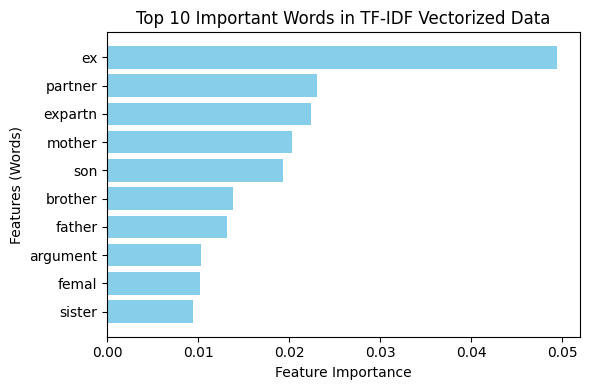

In [38]:
# Select the top N features for plotting
top_n = 10
top_features = sorted_word_importances[:top_n]
words, importances = zip(*top_features)  # This separates the words and their importances into two tuples

# Create a horizontal bar chart
plt.figure(figsize=(6, 4))
plt.barh(range(len(words)), importances, color='skyblue')
plt.yticks(range(len(words)), words)  # Set the y-ticks to be the words

plt.xlabel('Feature Importance')
plt.ylabel('Features (Words)')
plt.title('Top 10 Important Words in TF-IDF Vectorized Data')

# Invert y-axis to have the most important feature at the top
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plots/feature_imp.png')
plt.show()



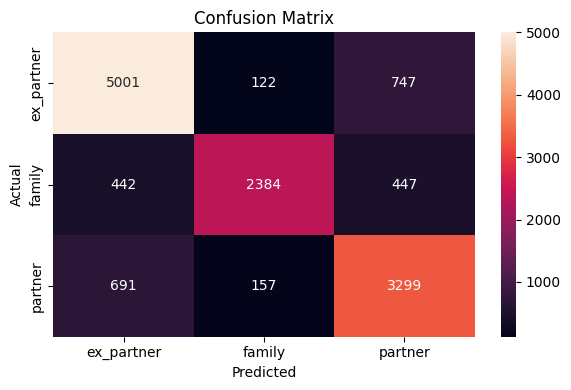

In [26]:
# error analysis - confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, all_predictions, labels=best_model.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plots/vict_off_confus_matrix.png')
plt.show()


In [1]:
from sklearn.metrics import classification_report

print(classification_report(y, all_predictions))


NameError: name 'y' is not defined

In [53]:
#  calculate the jaccard similarity between pairwise class combinations
from itertools import combinations

# store the class labels 
class_labels = list(best_model.classes_)

# init a dictionary to store jaccard sims
jaccard_sims = {}

# Use apply to get the type of each entry in the series
data_types = data_f4['text_processed_no_sw_stem'].apply(lambda x: type(x))

# Count occurrences of each data type
data_type_counts = data_types.value_counts()

# Print the counts of each data type
print(data_type_counts)


# split text into tokens
# data_f4.loc['text_processed_no_sw_stem_split'] = data_f4['text_processed_no_sw_stem'].apply(lambda x: x.split())

# #  iterate over each combination of classes
# for class1, class2 in combinations(class_labels, 2):
#     #  filter the dataset
#     text_class1 = data_f4[data_f4['remapped_cats']==class1]['text_processed_no_sw_stem_split']
#     text_class2 = data_f4[data_f4['remapped_cats']==class2]['text_processed_no_sw_stem_split']

    # compute the union and intersection of all tokens in each class
    # union = set().union(*text_class1).union(*text_class2)
    # intersection = set().intersection(*text_class1).intersection(text_class2)

#     # compute the jaccard similarity and store in dict
#     jaccard_sim = len(intersection) / len(union) if len(union) > 0 else 0
#     jaccard_sims[(class1, class2)] = jaccard_sim

# for classes, similarity in jaccard_sims.items():
#     print(f"Jaccard Similarity between {classes[0]} and {classes[1]}: {similarity}")

text_processed_no_sw_stem
<class 'str'>      13290
<class 'float'>        1
Name: count, dtype: int64


In [ ]:
from gensim.models import Word2Vec